# Step 3 — Baseline models for breach prediction

Four naive baselines at three forecast horizons (1, 2, 12 weeks) evaluated
on the held-out 2025 test set. This sets the bar that the LightGBM model in
step 4 needs to beat — most importantly **B3 PO×Week** at h=12 and
**B1 Persistence** at h=1.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.load_data import load_lice
from src.utils import make_supervised_frame, train_test_split_by_year, po_label
from src.baselines import all_baselines
from src.evaluation import score_baseline, pr_auc_by_po

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
})

FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR = ROOT / "reports"

HORIZONS = (1, 2, 12)

## 1. Load data and build supervised frames

In [2]:
lice = load_lice(apply_cutoff=True)
print(f"lice frame: {lice.shape}, "
      f"{lice['WEEK_START'].min().date()} → {lice['WEEK_START'].max().date()}")

frames = {h: make_supervised_frame(lice, horizon=h, counted_only=True)
          for h in HORIZONS}
splits = {h: train_test_split_by_year(frames[h]) for h in HORIZONS}

for h in HORIZONS:
    train, test = splits[h]
    print(f"  h={h:>2}w: train={len(train):>7,}  test={len(test):>6,}  "
          f"pos_rate_test={test['target'].mean():.3%}  "
          f"pos_rate_train={train['target'].mean():.3%}")

lice frame: (781280, 22), 2012-01-02 → 2025-12-22


  h= 1w: train=357,188  test=28,955  pos_rate_test=3.499%  pos_rate_train=4.552%
  h= 2w: train=357,381  test=28,368  pos_rate_test=3.543%  pos_rate_train=4.534%
  h=12w: train=359,315  test=22,949  pos_rate_test=4.026%  pos_rate_train=4.437%


## 2. Fit and evaluate every (baseline × horizon) combination

In [3]:
records = []
predictions = {}  # (baseline_name, horizon) -> (test_df, y_score)
for h in HORIZONS:
    train, test = splits[h]
    for b in all_baselines(horizon=h):
        b.fit(train)
        p = b.predict_proba(test)
        s = score_baseline(b.name, h, test, p)
        records.append(s.as_row())
        predictions[(b.name, h)] = (test, p)

summary = pd.DataFrame(records)
print(summary.to_string(index=False))

        baseline  horizon  n_test  pos_rate  PR-AUC  P@100   Brier  count_MAE
   B0 GlobalRate        1   28955    0.0350  0.0350   0.03 0.03387      13.49
  B1 Persistence        1   28955    0.0350  0.1897   0.38 0.04034       5.52
B2 SeasonalNaive        1   28955    0.0350  0.0383   0.04 0.05392       7.81
   B3 POWeekRate        1   28955    0.0350  0.0701   0.13 0.03330       8.04
   B0 GlobalRate        2   28368    0.0354  0.0354   0.03 0.03427      13.32
  B1 Persistence        2   28368    0.0354  0.0796   0.14 0.05263       8.47
B2 SeasonalNaive        2   28368    0.0354  0.0387   0.07 0.05465       7.76
   B3 POWeekRate        2   28368    0.0354  0.0710   0.14 0.03368       7.87
   B0 GlobalRate       12   22949    0.0403  0.0403   0.03 0.03866      12.28
  B1 Persistence       12   22949    0.0403  0.0466   0.12 0.05490      16.72
B2 SeasonalNaive       12   22949    0.0403  0.0445   0.05 0.06281       7.37
   B3 POWeekRate       12   22949    0.0403  0.0757   0.13 0.038

## 3. Headline table — PR-AUC, P@100, Brier, count-MAE per (baseline × horizon)

In [4]:
def pivot(metric: str) -> pd.DataFrame:
    return (summary.pivot(index="baseline", columns="horizon", values=metric)
            .reindex(["B0 GlobalRate", "B1 Persistence",
                      "B2 SeasonalNaive", "B3 POWeekRate"]))


pivots = {m: pivot(m) for m in ["PR-AUC", "P@100", "Brier", "count_MAE"]}
for m, tbl in pivots.items():
    print(f"\n— {m} —")
    print(tbl.round(4))


— PR-AUC —
horizon               1       2       12
baseline                                
B0 GlobalRate     0.0350  0.0354  0.0403
B1 Persistence    0.1897  0.0796  0.0466
B2 SeasonalNaive  0.0383  0.0387  0.0445
B3 POWeekRate     0.0701  0.0710  0.0757

— P@100 —
horizon             1     2     12
baseline                          
B0 GlobalRate     0.03  0.03  0.03
B1 Persistence    0.38  0.14  0.12
B2 SeasonalNaive  0.04  0.07  0.05
B3 POWeekRate     0.13  0.14  0.13

— Brier —
horizon               1       2       12
baseline                                
B0 GlobalRate     0.0339  0.0343  0.0387
B1 Persistence    0.0403  0.0526  0.0549
B2 SeasonalNaive  0.0539  0.0546  0.0628
B3 POWeekRate     0.0333  0.0337  0.0380

— count_MAE —
horizon              1      2      12
baseline                             
B0 GlobalRate     13.49  13.32  12.28
B1 Persistence     5.52   8.47  16.72
B2 SeasonalNaive   7.81   7.76   7.37
B3 POWeekRate      8.04   7.87   7.55


## 4. Headline chart — PR-AUC by horizon, all baselines

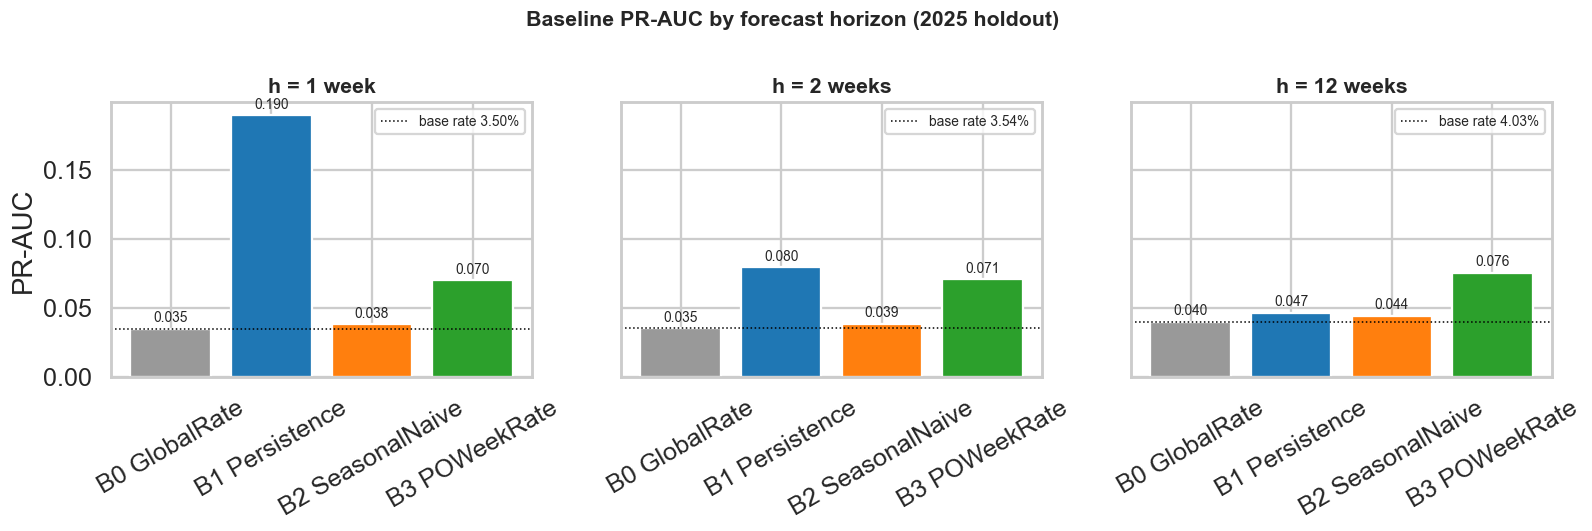

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
colors = {"B0 GlobalRate": "#999999",
          "B1 Persistence": "#1f77b4",
          "B2 SeasonalNaive": "#ff7f0e",
          "B3 POWeekRate": "#2ca02c"}

for ax, h in zip(axes, HORIZONS):
    row_subset = summary[summary["horizon"] == h]
    bars = ax.bar(row_subset["baseline"], row_subset["PR-AUC"],
                  color=[colors[b] for b in row_subset["baseline"]])
    ax.set_title(f"h = {h} week{'s' if h > 1 else ''}")
    ax.set_ylabel("PR-AUC" if ax is axes[0] else "")
    ax.tick_params(axis="x", rotation=30)
    # Base-rate reference line
    pos_rate = row_subset["pos_rate"].iloc[0]
    ax.axhline(pos_rate, color="black", linestyle=":", linewidth=1,
               label=f"base rate {pos_rate:.2%}")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{bar.get_height():.3f}", ha="center", fontsize=9)
    ax.legend(loc="upper right", fontsize=9)

fig.suptitle("Baseline PR-AUC by forecast horizon (2025 holdout)",
             fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "B1_baseline_pr_auc_by_horizon.png")
plt.show()

## 5. Per-PO breakdown — where does the strongest baseline fail?

Take B3 POWeekRate (the strongest naive at h=12) and break PR-AUC out by PO.
We expect: high in southern/mid-Norway POs where there's enough training
signal; low in cold-water POs (Finnmark) where the breach rate is so low
that PR-AUC has little to grade.


B3 POWeekRate PR-AUC by PO (NaN = no positives in test):
                                 h=1w   h=2w  h=12w
PO1: Svenskegrensen til Jæren   0.009  0.009  0.003
PO2: Ryfylket                   0.103  0.103  0.108
PO3: Karmøy til Sotra           0.059  0.062  0.072
PO4: Nordhord. til Stadt        0.053  0.056  0.060
PO5: Stadt til Hustadvika       0.055  0.055  0.055
PO6: Nordmøre og S-Trønd.       0.123  0.124  0.127
PO7: N-Trønd. med Bindal        0.046  0.046  0.049
PO8: Helgeland til Bodø         0.082  0.082  0.084
PO9: Vestfjorden og Vesterålen  0.057  0.057  0.061
PO10: Andøya til Senja          0.066  0.066  0.068
PO11: Kvaløya til Loppa         0.050  0.050  0.057
PO12: Vest-Finnmark             0.021  0.021  0.023
PO13: Øst-Finnmark                NaN    NaN    NaN


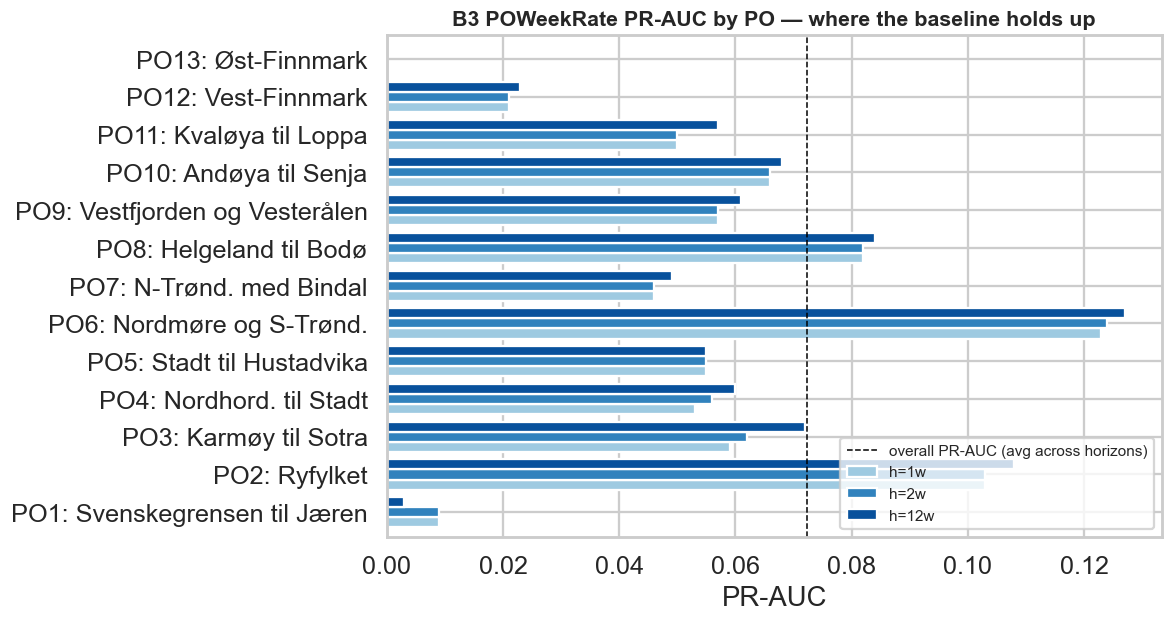

In [6]:
breakdown_rows = []
po_id_to_label = (lice.dropna(subset=["PRODUCTIONAREA", "PRODUCTIONAREAID"])
                  .groupby("PRODUCTIONAREAID")["PRODUCTIONAREA"]
                  .agg(lambda s: s.mode().iloc[0]))

for h in HORIZONS:
    test, p = predictions[("B3 POWeekRate", h)]
    by_po = pr_auc_by_po(test, p)
    by_po.index = [po_label(po_id, po_id_to_label.get(po_id, "Unknown"))
                   for po_id in by_po.index]
    by_po.name = f"h={h}w"
    breakdown_rows.append(by_po)

breakdown = pd.concat(breakdown_rows, axis=1).round(3)
print("\nB3 POWeekRate PR-AUC by PO (NaN = no positives in test):")
print(breakdown)

fig, ax = plt.subplots(figsize=(11, 6))
breakdown.plot.barh(ax=ax, color=["#9ecae1", "#3182bd", "#08519c"], width=0.8)
ax.axvline(summary[summary["baseline"] == "B3 POWeekRate"]["PR-AUC"].mean(),
           color="black", linestyle="--", linewidth=1,
           label="overall PR-AUC (avg across horizons)")
ax.set_xlabel("PR-AUC")
ax.set_ylabel("")
ax.set_title("B3 POWeekRate PR-AUC by PO — where the baseline holds up")
ax.legend(loc="lower right", fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / "B2_baseline_pr_auc_by_po.png")
plt.show()

## 6. Persist results to JSON so step 4 can compare

In [7]:
output = {
    "horizons": list(HORIZONS),
    "summary_rows": records,
    "metric_tables": {m: tbl.round(5).to_dict() for m, tbl in pivots.items()},
    "po_breakdown": breakdown.round(5).to_dict(),
}
(MODELS_DIR / "baselines.json").write_text(
    json.dumps(output, indent=2, default=str), encoding="utf-8")
print(f"Saved to {MODELS_DIR / 'baselines.json'}")

Saved to C:\Users\joerg\Documents\MowiOppg\models\baselines.json


## 7. One-page summary for the deck

In [8]:
def fmt_pivot(tbl: pd.DataFrame) -> str:
    return tbl.round(4).to_markdown()


# Identify the strongest baseline per horizon by PR-AUC
strongest = (summary.sort_values(["horizon", "PR-AUC"], ascending=[True, False])
             .groupby("horizon").first())

deck_md = f"""# Baseline results — step 3

Test set: **2025 holdout** (untouched in development).
Training: 2012-01-02 → 2024-12-29.
Metric primary: **PR-AUC** (base rate {summary['pos_rate'].mean():.2%}, accuracy is useless here).

## PR-AUC by horizon

{fmt_pivot(pivots['PR-AUC'])}

## Precision-at-100 by horizon

{fmt_pivot(pivots['P@100'])}

## Count-MAE by horizon (weekly aggregate)

{fmt_pivot(pivots['count_MAE'])}

## Strongest baseline per horizon

{strongest[['baseline', 'PR-AUC', 'P@100', 'count_MAE']].to_markdown()}

## What this tells us for step 4

- **At h=1** the bar to beat is **B1 Persistence** (PR-AUC {pivots['PR-AUC'].loc['B1 Persistence', 1]:.3f}).
  Recent lice counts dominate — any model that doesn't use lag features will fail here.
- **At h=12** the bar to beat is **B3 POWeekRate** (PR-AUC {pivots['PR-AUC'].loc['B3 POWeekRate', 12]:.3f}).
  Persistence breaks down over 12 weeks, so PO + seasonality become the dominant signal.
  Beating this requires temperature and treatment features.
- The **per-PO breakdown** shows baselines are blind in the Finnmark POs
  (insufficient positives) — a model that handles low-base-rate POs better
  will be a real improvement.
"""

(REPORTS_DIR / "baselines_summary.md").write_text(deck_md, encoding="utf-8")
print(deck_md)

# Baseline results — step 3

Test set: **2025 holdout** (untouched in development).
Training: 2012-01-02 → 2024-12-29.
Metric primary: **PR-AUC** (base rate 3.69%, accuracy is useless here).

## PR-AUC by horizon

| baseline         |      1 |      2 |     12 |
|:-----------------|-------:|-------:|-------:|
| B0 GlobalRate    | 0.035  | 0.0354 | 0.0403 |
| B1 Persistence   | 0.1897 | 0.0796 | 0.0466 |
| B2 SeasonalNaive | 0.0383 | 0.0387 | 0.0445 |
| B3 POWeekRate    | 0.0701 | 0.071  | 0.0757 |

## Precision-at-100 by horizon

| baseline         |    1 |    2 |   12 |
|:-----------------|-----:|-----:|-----:|
| B0 GlobalRate    | 0.03 | 0.03 | 0.03 |
| B1 Persistence   | 0.38 | 0.14 | 0.12 |
| B2 SeasonalNaive | 0.04 | 0.07 | 0.05 |
| B3 POWeekRate    | 0.13 | 0.14 | 0.13 |

## Count-MAE by horizon (weekly aggregate)

| baseline         |     1 |     2 |    12 |
|:-----------------|------:|------:|------:|
| B0 GlobalRate    | 13.49 | 13.32 | 12.28 |
| B1 Persistence   |  5.52 |  8.4